**Prática de Histogramas**

1) 
- Produza a imagem ‘negativa’ do arquivo ‘im_cells.png’
- Com a imagem negativa, produza a imagem original novamente. 
- Mostre lado a lado a imagem original e a negativa. Em qual deles os objetos presentes na imagem são melhor percebidos? Justifique.
- Aplique a imagem uma função logarítmica.


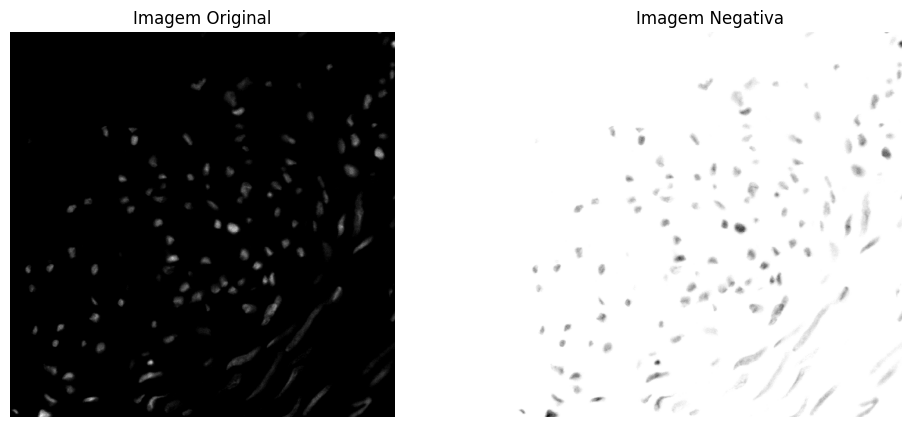

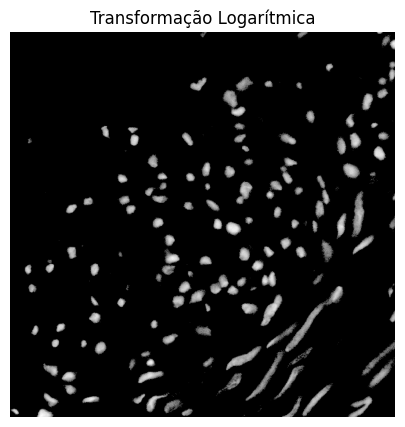

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_original = cv2.imread('im_cells.png', cv2.IMREAD_GRAYSCALE)

img_negativa = 255 - img_original

img_reconstruida = 255 - img_negativa

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_original, cmap='gray')
plt.title('Imagem Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_negativa, cmap='gray')
plt.title('Imagem Negativa')
plt.axis('off')

plt.show()

c = 255 / np.log(1 + np.max(img_original))
img_log = c * (np.log(1 + img_original.astype(np.float32)))

img_log = np.array(img_log, dtype=np.uint8)

plt.figure(figsize=(6, 5))
plt.imshow(img_log, cmap='gray')
plt.title('Transformação Logarítmica')
plt.axis('off')
plt.show()


O meu grupo entrou em uma briga sobre em qual imagem os objetos são melhor percebido, no fim 2/4 acha que a imagem original é melhor e a outra metade acha que a imagem negativa é melhor.

2)
- Abra a imagem 'pout.tif' e mostre seu histograma.
- Equalize a imagem anterior e mostre novamente seu histograma. Mostra a curva de transformação (consulte https://www.mathworks.com/help/images/histogram-equalization.html)
(procurar função OpenCV)



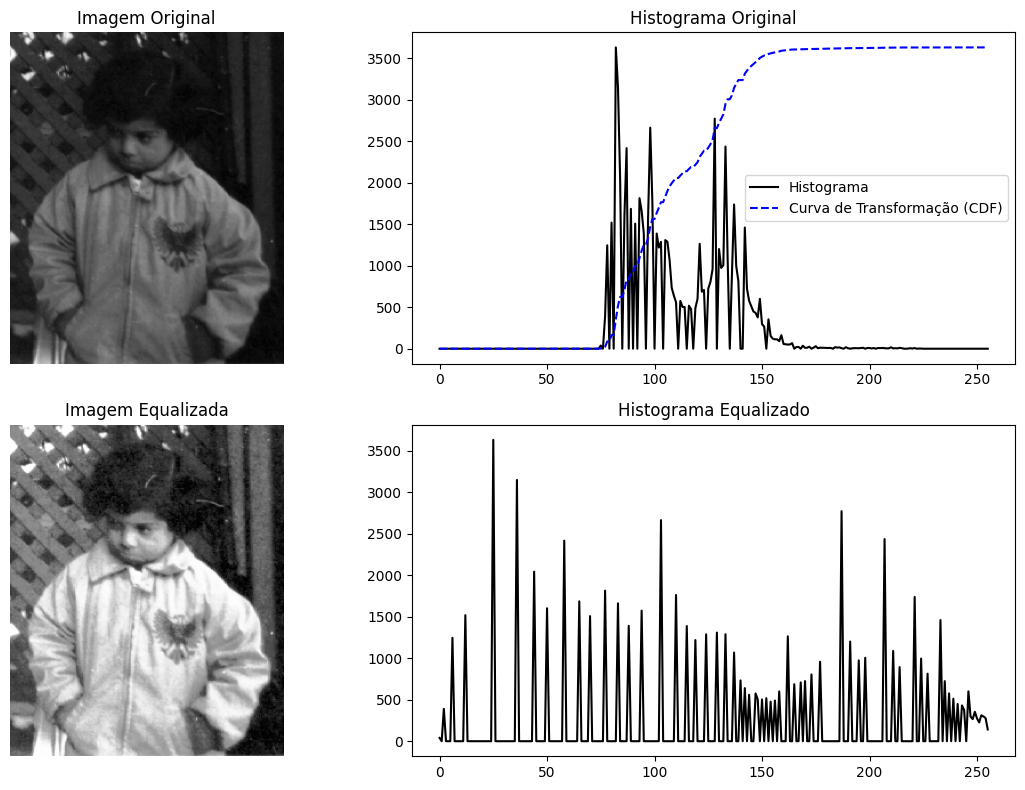

In [9]:
img = cv2.imread('pout.tif', cv2.IMREAD_GRAYSCALE)

hist_original = cv2.calcHist([img], [0], None, [256], [0, 256])
img_eq = cv2.equalizeHist(img)
hist_eq = cv2.calcHist([img_eq], [0], None, [256], [0, 256])

cdf = hist_original.cumsum()
cdf_normalized = cdf * float(hist_original.max()) / cdf.max() 

cdf_eq = hist_eq.cumsum()
cdf_eq_normalized = cdf_eq * float(hist_eq.max()) / cdf_eq.max()

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Imagem Original')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.plot(hist_original, color='black', label='Histograma')
plt.plot(cdf_normalized, color='blue', linestyle='--', label='Curva de Transformação (CDF)')
plt.title('Histograma Original')
plt.legend()

plt.subplot(2, 2, 3)
plt.imshow(img_eq, cmap='gray')
plt.title('Imagem Equalizada')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.plot(hist_eq, color='black')
plt.title('Histograma Equalizado')

plt.tight_layout()
plt.savefig('resultado_pout_hist.png') 
plt.show()

3) *Implemente* o algoritmo de equalização de histograma e aplique a imagem ‘imcells.png’. Use o mínimos de laços for - tente realizar operações diretas com matrizes e vetores do numpy
- Aplique o mesmo algortimo 2x na mesma imagem e compare os resultados

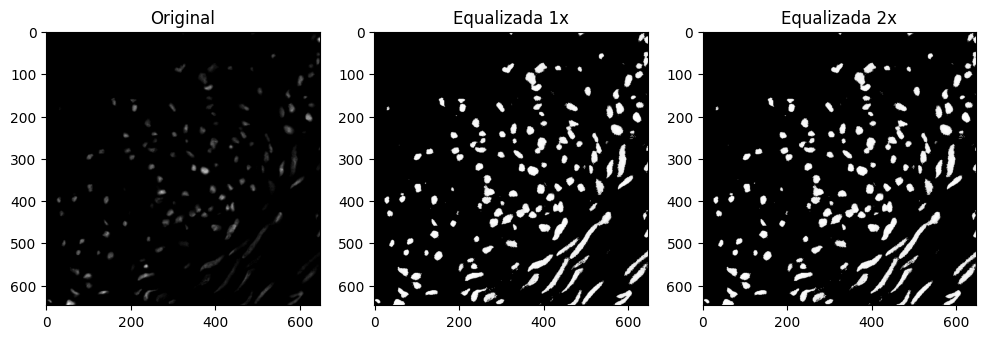

In [ ]:
# code here
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('im_cells.png', 0)

def equalizar(imagem_entrada):
    hist, _ = np.histogram(imagem_entrada.flatten(), 256, [0, 256])
    
    cdf = hist.cumsum()
    cdf_normalizada = (cdf / cdf.max()) * 255
    
    tabela_equalizacao = cdf_normalizada.astype('uint8')
    
    return tabela_equalizacao[imagem_entrada]

if img is None:
    print("Erro: Imagem não encontrada.")
else:
    img_1x = equalizar(img)
    img_2x = equalizar(img_1x)
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    
    plt.subplot(1, 3, 2)
    plt.imshow(img_1x, cmap='gray')
    plt.title("Equalizada 1x")
    
    plt.subplot(1, 3, 3)
    plt.imshow(img_2x, cmap='gray')
    plt.title("Equalizada 2x")
    
    plt.show()